# 1. Thư viện và dữ liệu

In [22]:
import pandas as pd
from src.processing.aggregate import prepare_level_data
from src.model.prophet import ProphetModel
from src.model.arima import ARIMAModel


In [23]:
file_path = "../data/time_series_country.csv"
df = pd.read_csv(file_path, sep=",", engine="python")


# 2.Dự báo tỷ lệ tử vong

## 2.1. Global model

In [24]:
global_df = prepare_level_data(df, level="global")
global_model = ARIMAModel(global_df)

In [25]:
forecast_df =global_model.arima_forecast(0, 1, 0, steps=6)
print(forecast_df)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              1.097062  1.871337      -2.570691       4.764815
26              1.097062  2.646470      -4.089924       6.284048
27              1.097062  3.241250      -5.255672       7.449796
28              1.097062  3.742674      -6.238444       8.432567
29              1.097062  4.184436      -7.104283       9.298406
30              1.097062  4.583820      -7.887061      10.081185


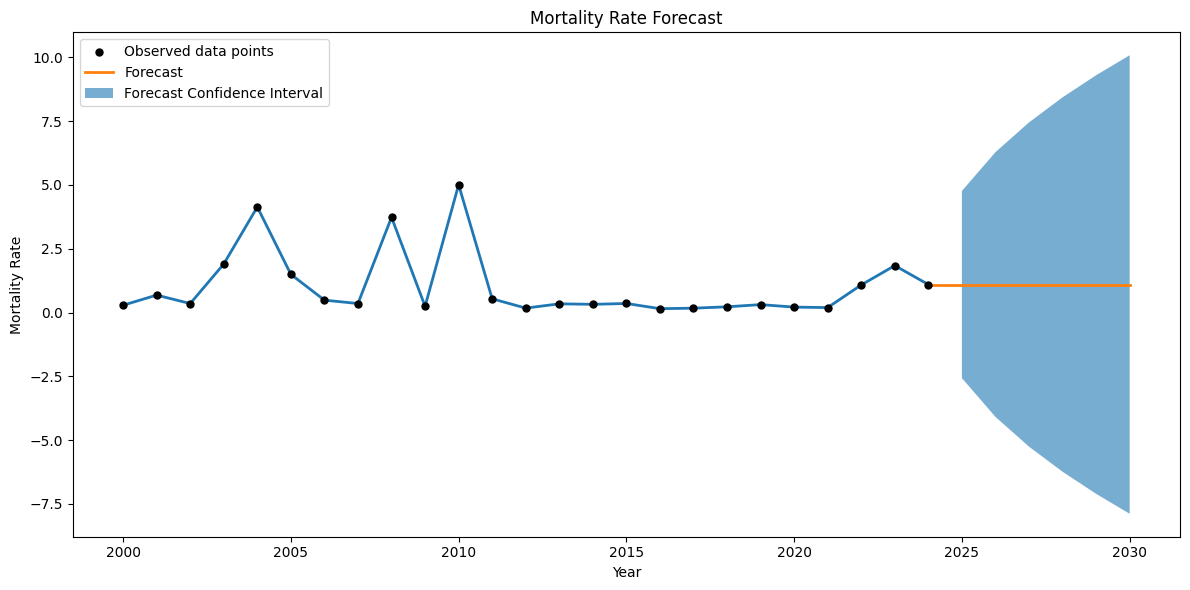

In [26]:
global_model.plot_forecast(0, 1, 0, steps=6)

## 2.2. Region Level

### 2.2.1. South Asia

In [27]:
south_asia = prepare_level_data(df,level='region', filter='South Asia')
south_asia_model = ARIMAModel(south_asia)
south_asia_forecast = south_asia_model.arima_forecast(0, 1, 1, steps=6)

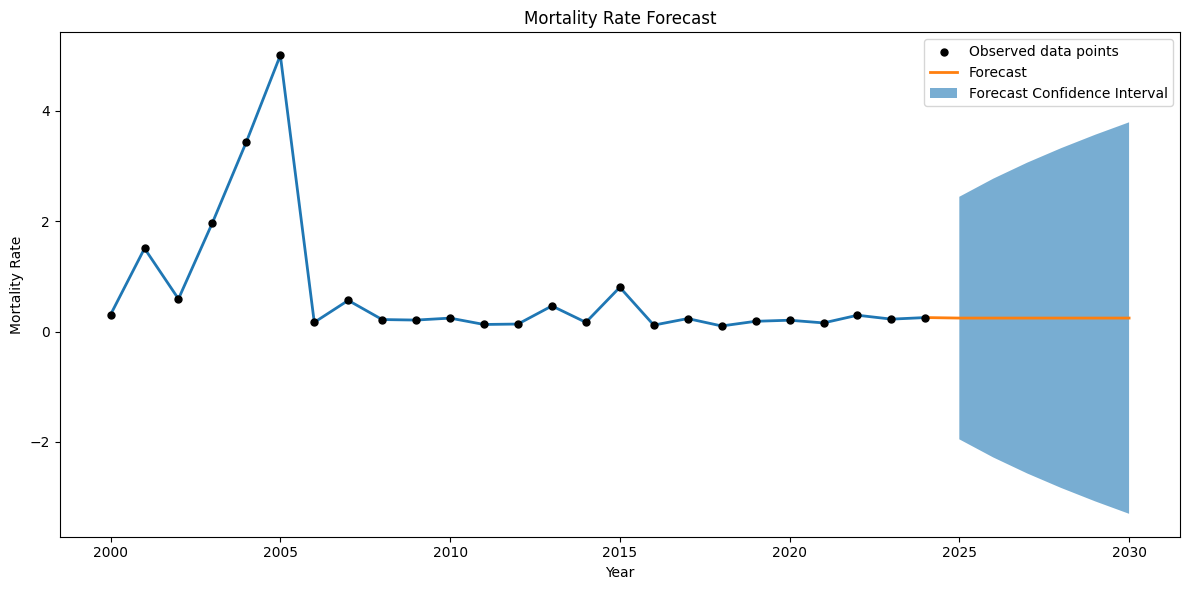

In [28]:
south_asia_model.plot_forecast(0, 1, 1, steps=6)

### 2.2.2. Europe and Central Asia

In [29]:
europe_central_asia= prepare_level_data(df,level='region', filter='Europe and Central Asia')
europe_central_asia_model = ProphetModel(europe_central_asia)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2003, 2010, 2022, 2023, 2024]
europe_central_asia_forecast = europe_central_asia_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(europe_central_asia_forecast)

17:31:03 - cmdstanpy - INFO - Chain [1] start processing
17:31:04 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31 -0.192328   -1.151151    0.729533    -0.192328    -0.192328   
26 2026-12-31 -0.222577   -1.151123    0.732527    -0.222577    -0.222577   
27 2027-12-31 -0.252825   -1.180337    0.706521    -0.252825    -0.252825   
28 2028-12-31 -0.283157   -1.139193    0.630125    -0.283157    -0.283157   
29 2029-12-31 -0.313405   -1.249711    0.631869    -0.313405    -0.313405   
30 2030-12-31 -0.343654   -1.282517    0.590056    -0.343654    -0.343653   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:31:05 - cmdstanpy - INFO - Chain [1] start processing
17:31:05 - cmdstanpy - INFO - Chain [1] done processing


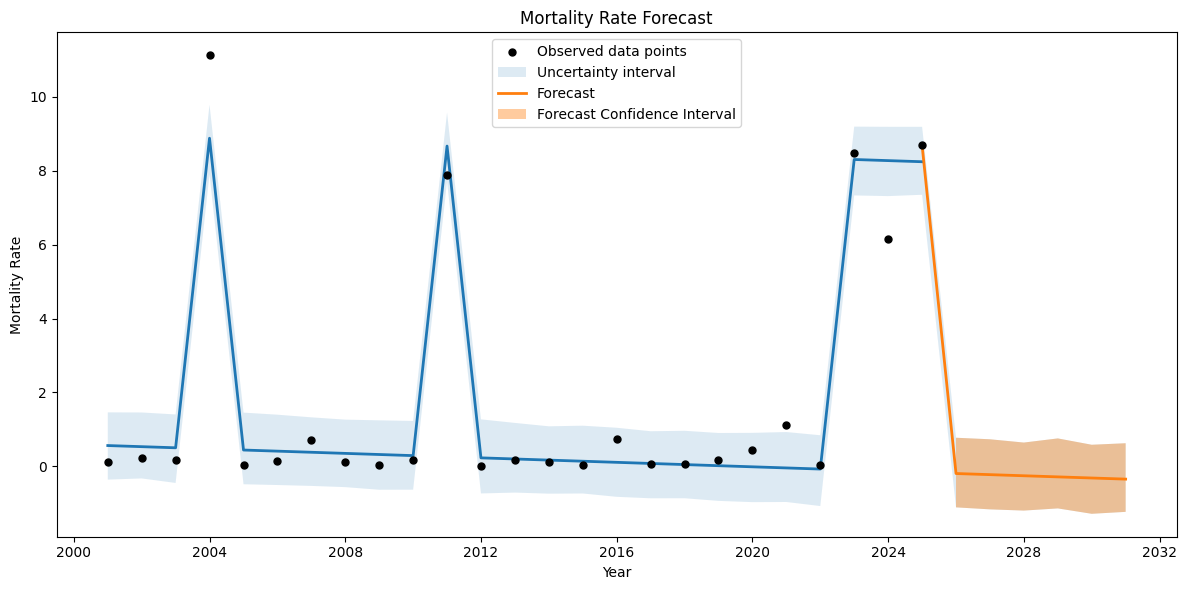

In [30]:
europe_central_asia_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.3. Middle East and North Africa

In [31]:
middle_east_north_africa = prepare_level_data(df,level='region', filter='Middle East and North Africa')
middle_east_north_africa_model = ARIMAModel(middle_east_north_africa)
middle_east_north_africa_forecast = middle_east_north_africa_model.arima_forecast(1, 0, 1, steps=6)
print(middle_east_north_africa_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25             -0.251009  4.610928      -9.288261       8.786243
26             -0.068071  4.639864      -9.162037       9.025895
27              0.089153  4.661122      -9.046477       9.224784
28              0.224278  4.676762      -8.942006       9.390562
29              0.340410  4.688280      -8.848450       9.529270
30              0.440218  4.696770      -8.765282       9.645718


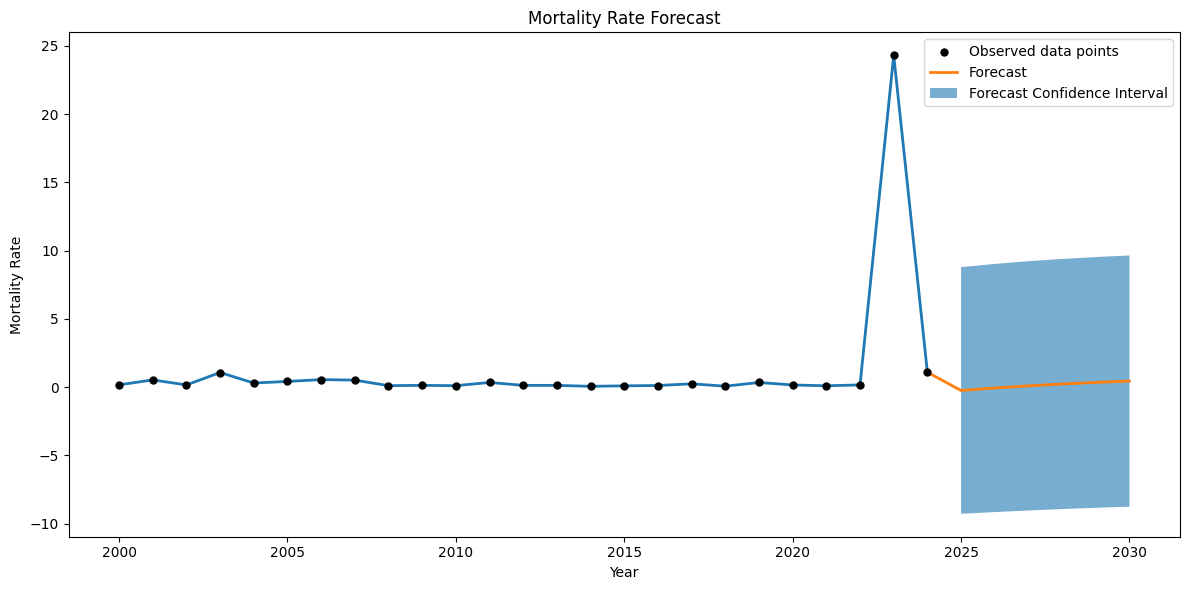

In [32]:
middle_east_north_africa_model.plot_forecast(1, 0, 1, steps=6)

### 2.2.4. East Asia and Pacific

In [33]:
east_asia_pacific = prepare_level_data(df,level='region', filter='East Asia and Pacific')
east_asia_pacific_model = ProphetModel(east_asia_pacific)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(10.0)
}
holiday_years = [2004, 2008, 2011]
east_asia_pacific_forecast = east_asia_pacific_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(east_asia_pacific_forecast)

17:32:46 - cmdstanpy - INFO - Chain [1] start processing
17:32:46 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31 -0.122718   -1.885225    1.616703    -0.122718    -0.122718   
26 2026-12-31 -0.148197   -1.972648    1.573537    -0.148197    -0.148197   
27 2027-12-31 -0.173676   -1.915497    1.681613    -0.173676    -0.173676   
28 2028-12-31 -0.199225   -2.043655    1.638396    -0.199225    -0.199225   
29 2029-12-31 -0.224704   -2.146124    1.600672    -0.224704    -0.224704   
30 2030-12-31 -0.250183   -1.991671    1.548299    -0.250183    -0.250183   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:32:48 - cmdstanpy - INFO - Chain [1] start processing
17:32:48 - cmdstanpy - INFO - Chain [1] done processing


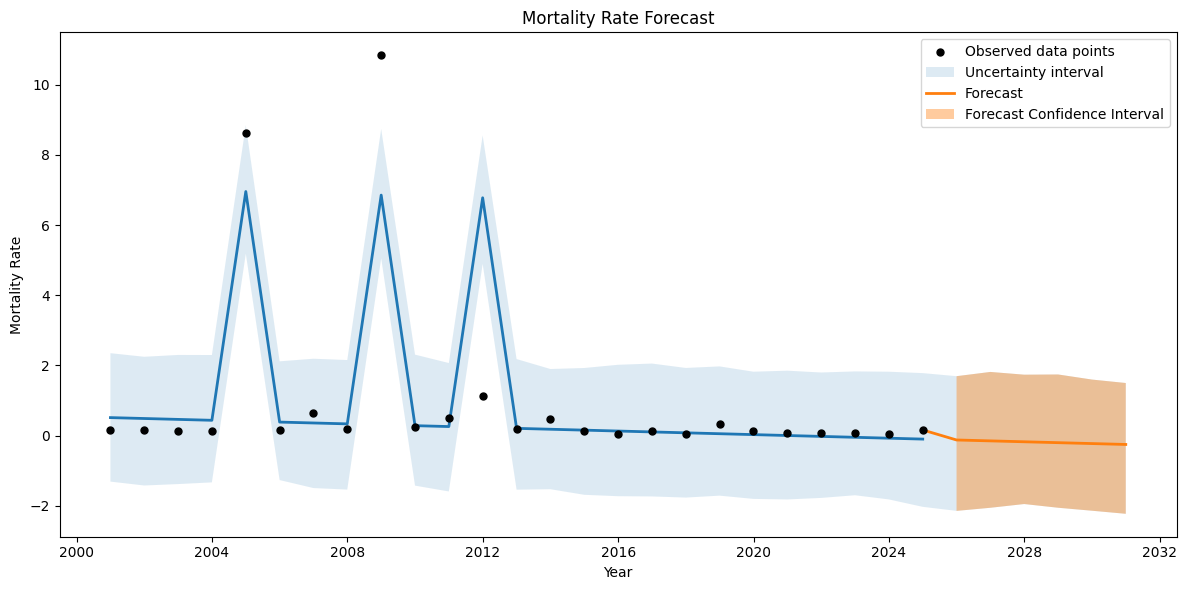

In [34]:
east_asia_pacific_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.5. Sub-Saharan Africa

In [35]:
subsaharan_africa = prepare_level_data(df,level='region', filter='Sub-Saharan Africa')
subsaharan_africa_model = ProphetModel(subsaharan_africa)
best_params = {
    "changepoint_prior_scale": float(0.2),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2010, 2014]
subsaharan_africa_forecast = subsaharan_africa_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(subsaharan_africa_forecast)

17:33:32 - cmdstanpy - INFO - Chain [1] start processing
17:33:32 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.610528    0.228933    0.954029     0.607537     0.613340   
26 2026-12-31  0.636273    0.277947    0.984855     0.626556     0.645080   
27 2027-12-31  0.662018    0.320638    1.018655     0.643633     0.678473   
28 2028-12-31  0.687834    0.342731    1.045242     0.658810     0.714616   
29 2029-12-31  0.713579    0.368173    1.041766     0.673011     0.752833   
30 2030-12-31  0.739324    0.370032    1.088114     0.685957     0.790609   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:33:33 - cmdstanpy - INFO - Chain [1] start processing
17:33:33 - cmdstanpy - INFO - Chain [1] done processing


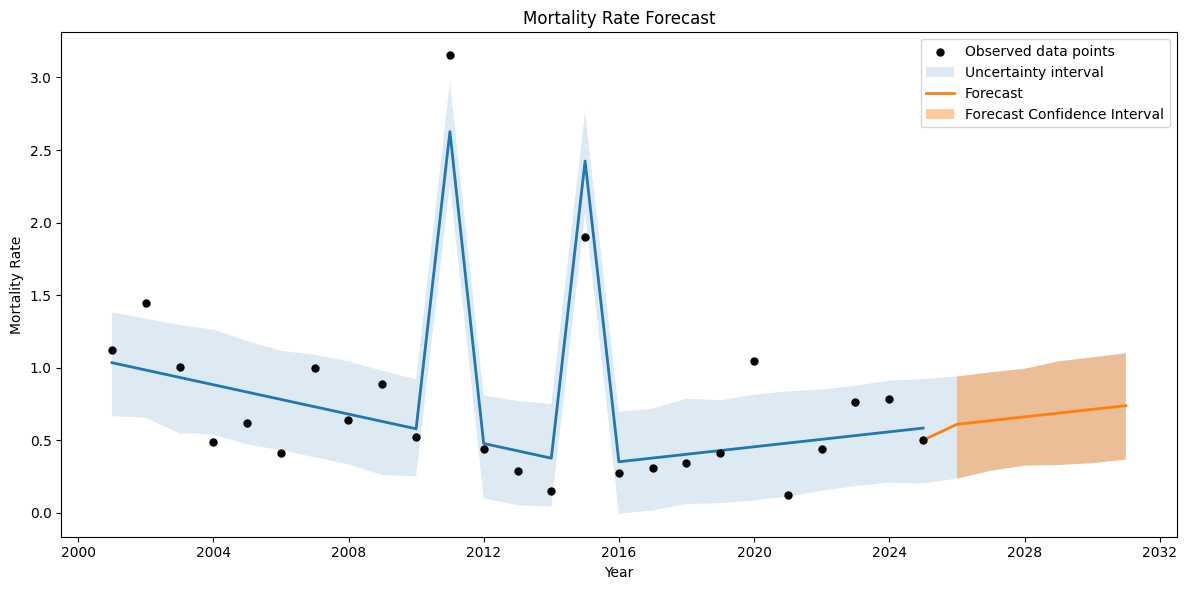

In [36]:
subsaharan_africa_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.6. Latin America and Caribbean

In [37]:
latin_america_caribbean = prepare_level_data(df,level='region', filter='Latin America and Caribbean')
latin_america_caribbean_model = ProphetModel(latin_america_caribbean)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2010]
latin_america_caribbean_forecast = latin_america_caribbean_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(latin_america_caribbean_forecast)

17:34:07 - cmdstanpy - INFO - Chain [1] start processing
17:34:07 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.220883   -0.012104    0.463813     0.212770     0.230178   
26 2026-12-31  0.222211   -0.028178    0.473257     0.196160     0.250698   
27 2027-12-31  0.223538   -0.006020    0.462595     0.176134     0.276821   
28 2028-12-31  0.224870   -0.007238    0.492396     0.152263     0.305254   
29 2029-12-31  0.226197   -0.043375    0.503989     0.120339     0.339905   
30 2030-12-31  0.227525   -0.034481    0.530298     0.088531     0.376899   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:34:10 - cmdstanpy - INFO - Chain [1] start processing
17:34:10 - cmdstanpy - INFO - Chain [1] done processing


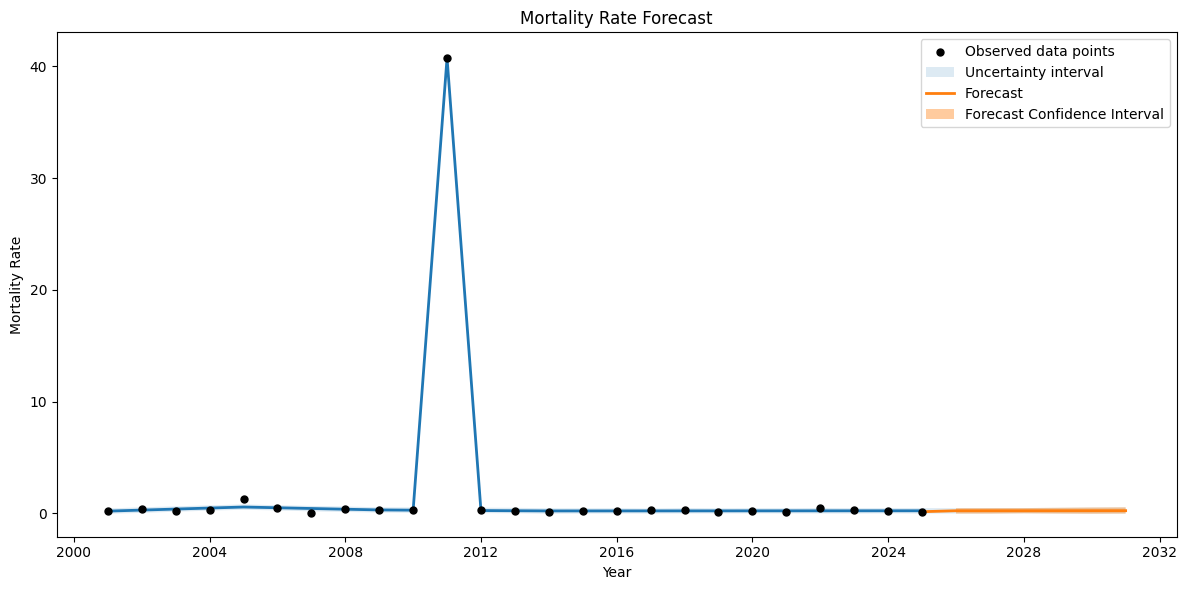

In [38]:
latin_america_caribbean_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.7. North America

In [39]:
north_america = prepare_level_data(df,level='region', filter='North America')
north_america_model = ProphetModel(north_america)
best_params = {
    "changepoint_prior_scale": float(0.5),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2005,2011, 2021, 2024]
north_america_forecast = north_america_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(north_america_forecast)

17:34:37 - cmdstanpy - INFO - Chain [1] start processing
17:34:37 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.121115    0.055140    0.184228     0.119286     0.122645   
26 2026-12-31  0.126725    0.062791    0.187690     0.120590     0.131550   
27 2027-12-31  0.132334    0.067371    0.189989     0.121002     0.141694   
28 2028-12-31  0.137960    0.073294    0.201184     0.120278     0.153314   
29 2029-12-31  0.143569    0.075601    0.205677     0.118937     0.165114   
30 2030-12-31  0.149179    0.076307    0.211089     0.116049     0.178158   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:34:39 - cmdstanpy - INFO - Chain [1] start processing
17:34:39 - cmdstanpy - INFO - Chain [1] done processing


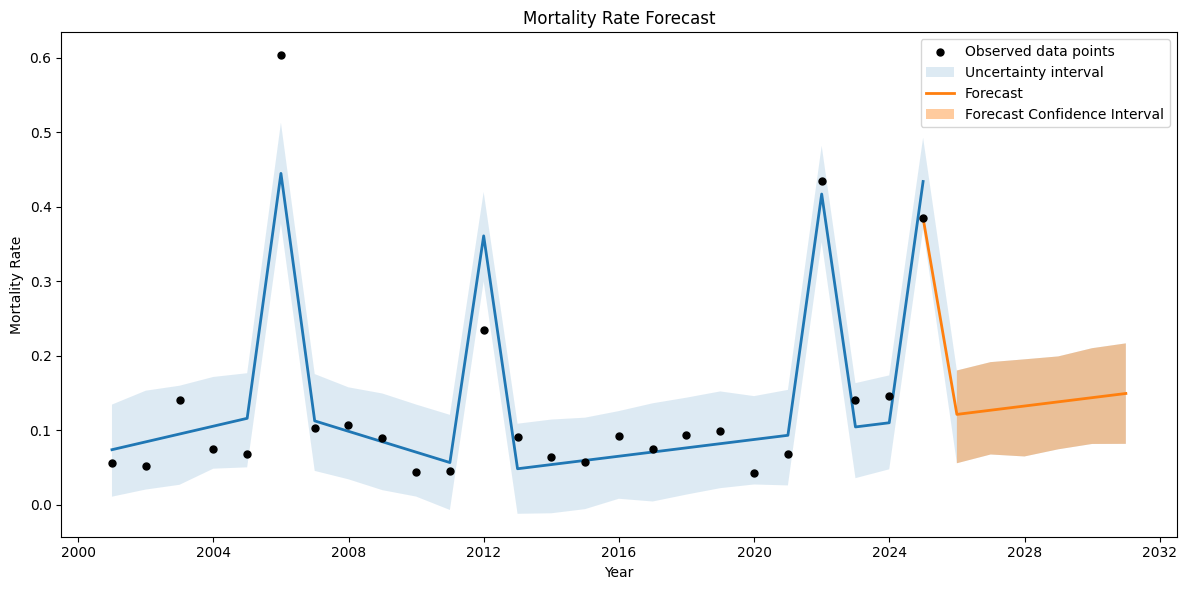

In [40]:
north_america_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

## 2.3. Country Level

### 2.3.1. Viet Nam

In [41]:
vietnam = prepare_level_data(df,level='country', filter='Viet Nam')
vietnam_model = ProphetModel(vietnam)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = []
vietnam_forecast = vietnam_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(vietnam_forecast)

17:35:44 - cmdstanpy - INFO - Chain [1] start processing
17:35:44 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.056955   -0.154066    0.262510     0.056955     0.056955   
26 2026-12-31  0.040974   -0.164995    0.249023     0.040974     0.040974   
27 2027-12-31  0.024993   -0.185579    0.242100     0.024993     0.024993   
28 2028-12-31  0.008969   -0.207685    0.215006     0.008969     0.008969   
29 2029-12-31 -0.007012   -0.207998    0.204647    -0.007012    -0.007012   
30 2030-12-31 -0.022993   -0.218730    0.179619    -0.022993    -0.022993   

    additive_terms  additive_terms_lower  additive_terms_upper  \
25             0.0                   0.0                   0.0   
26             0.0                   0.0                   0.0   
27             0.0                   0.0                   0.0   
28             0.0                   0.0                   0.0   
29             0.0                   0.0                   0.0   
30             0.0                   0.0                   0.0  

17:35:50 - cmdstanpy - INFO - Chain [1] start processing
17:35:50 - cmdstanpy - INFO - Chain [1] done processing


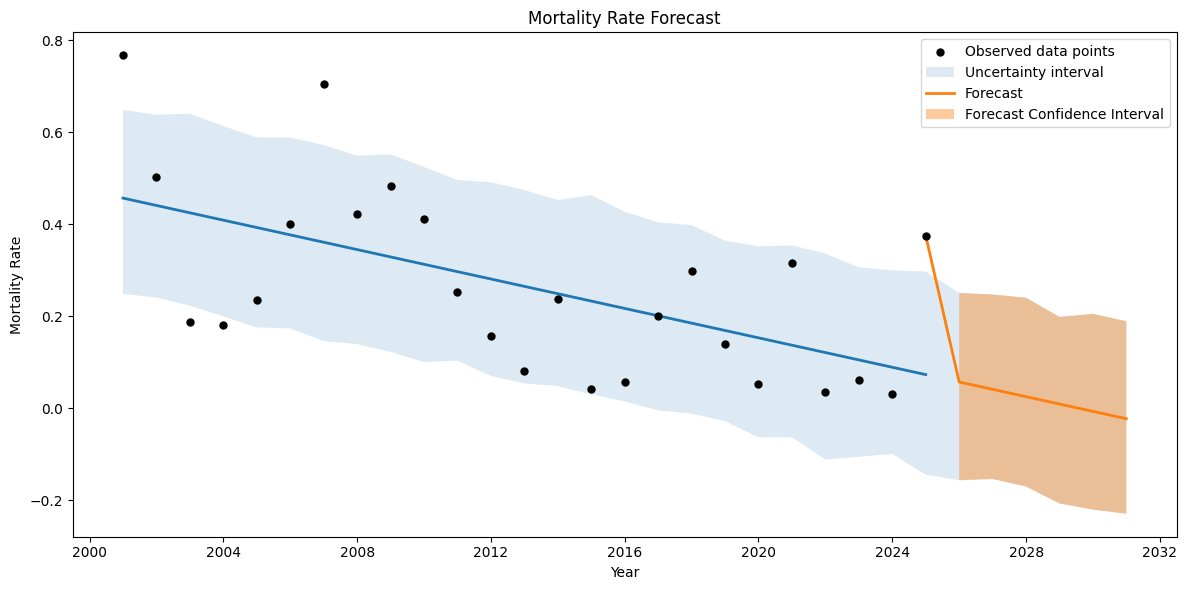

In [42]:
vietnam_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.2. Japan

In [43]:
japan = prepare_level_data(df,level='country', filter='Japan')
japan_model = ProphetModel(japan)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2011]
japan_forecast = japan_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(japan_forecast)

17:37:27 - cmdstanpy - INFO - Chain [1] start processing
17:37:27 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.217020    0.068346    0.361475     0.217009     0.217031   
26 2026-12-31  0.224105    0.077882    0.384114     0.224068     0.224140   
27 2027-12-31  0.231189    0.075479    0.378236     0.231119     0.231260   
28 2028-12-31  0.238292    0.082954    0.395261     0.238182     0.238408   
29 2029-12-31  0.245377    0.094074    0.403065     0.245217     0.245543   
30 2030-12-31  0.252461    0.098082    0.410850     0.252251     0.252669   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:37:30 - cmdstanpy - INFO - Chain [1] start processing
17:37:30 - cmdstanpy - INFO - Chain [1] done processing


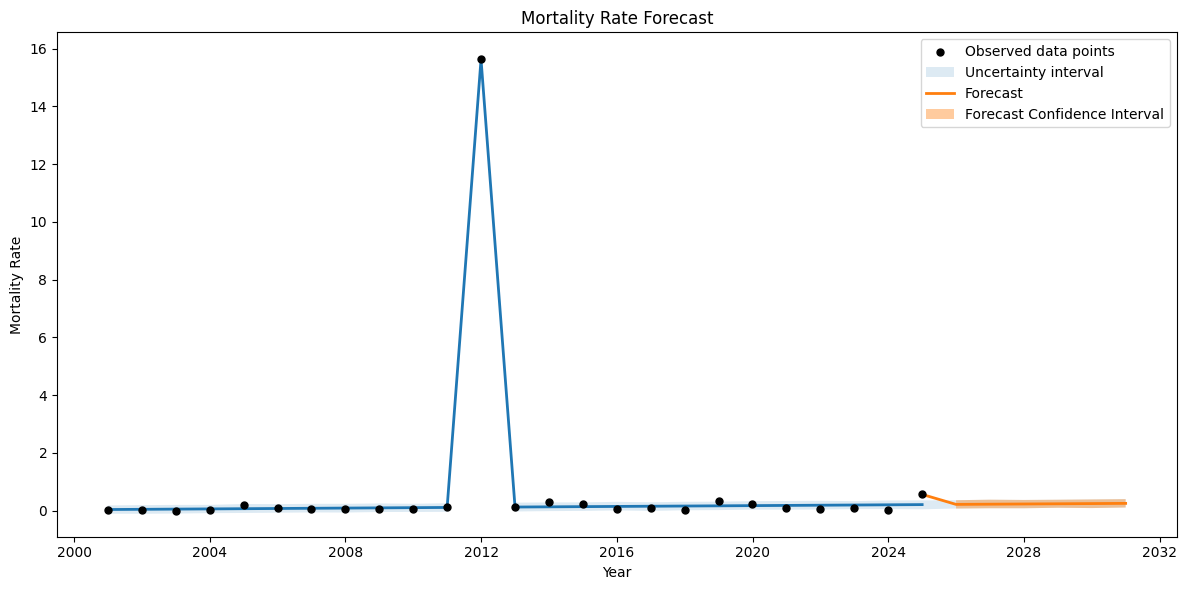

In [44]:
japan_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.3. France

In [45]:
france = prepare_level_data(df,level='country', filter='France')
france_model = ARIMAModel(france)
france_forecast = france_model.arima_forecast(0, 0, 0, steps=6)
print(france_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              2.343283  6.216549      -9.840929      14.527495
26              2.343283  6.216549      -9.840929      14.527495
27              2.343283  6.216549      -9.840929      14.527495
28              2.343283  6.216549      -9.840929      14.527495
29              2.343283  6.216549      -9.840929      14.527495
30              2.343283  6.216549      -9.840929      14.527495


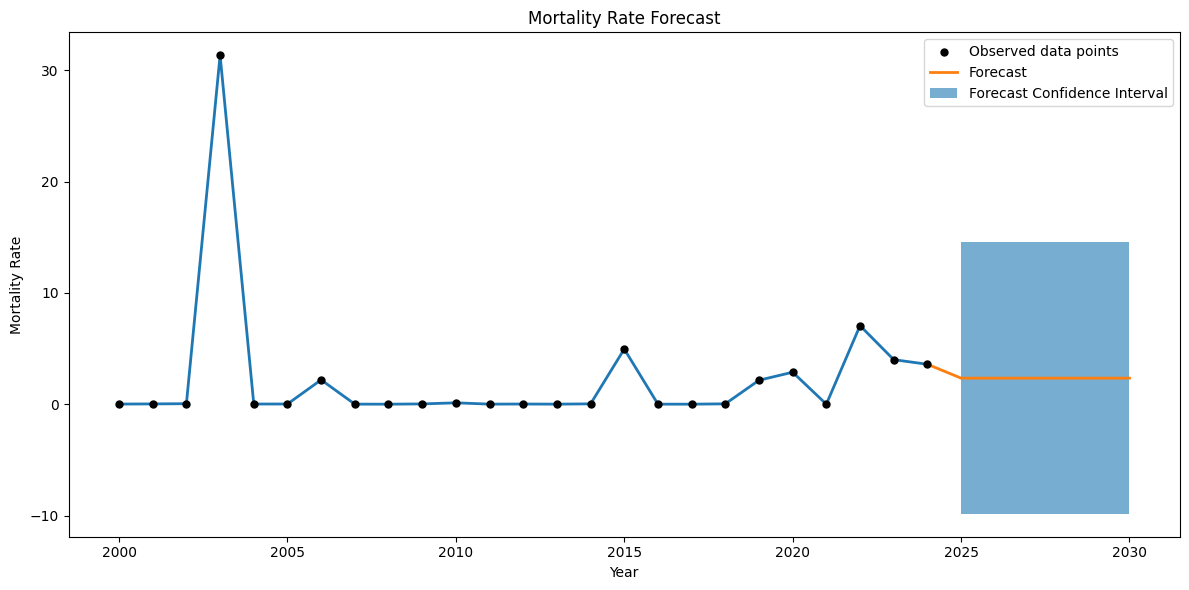

In [46]:
france_model.plot_forecast(0, 0, 0, steps=6)

### 2.3.4. Italy

In [49]:
italy = prepare_level_data(df,level='country', filter='Italy')
italy_model = ProphetModel(italy)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(10.0)
}
holiday_years = [2003,2022,2023,2024]
italy_forecast = italy_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(italy_forecast)

17:40:43 - cmdstanpy - INFO - Chain [1] start processing
17:40:43 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31 -1.169082   -3.651690    1.252430    -1.169082    -1.169082   
26 2026-12-31 -1.257345   -3.622311    0.977168    -1.257345    -1.257344   
27 2027-12-31 -1.345607   -3.750006    1.288213    -1.345608    -1.345606   
28 2028-12-31 -1.434111   -3.945100    1.181069    -1.434112    -1.434110   
29 2029-12-31 -1.522374   -4.123825    0.751680    -1.522375    -1.522372   
30 2030-12-31 -1.610636   -4.048333    0.934227    -1.610638    -1.610634   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:40:21 - cmdstanpy - INFO - Chain [1] start processing
17:40:22 - cmdstanpy - INFO - Chain [1] done processing


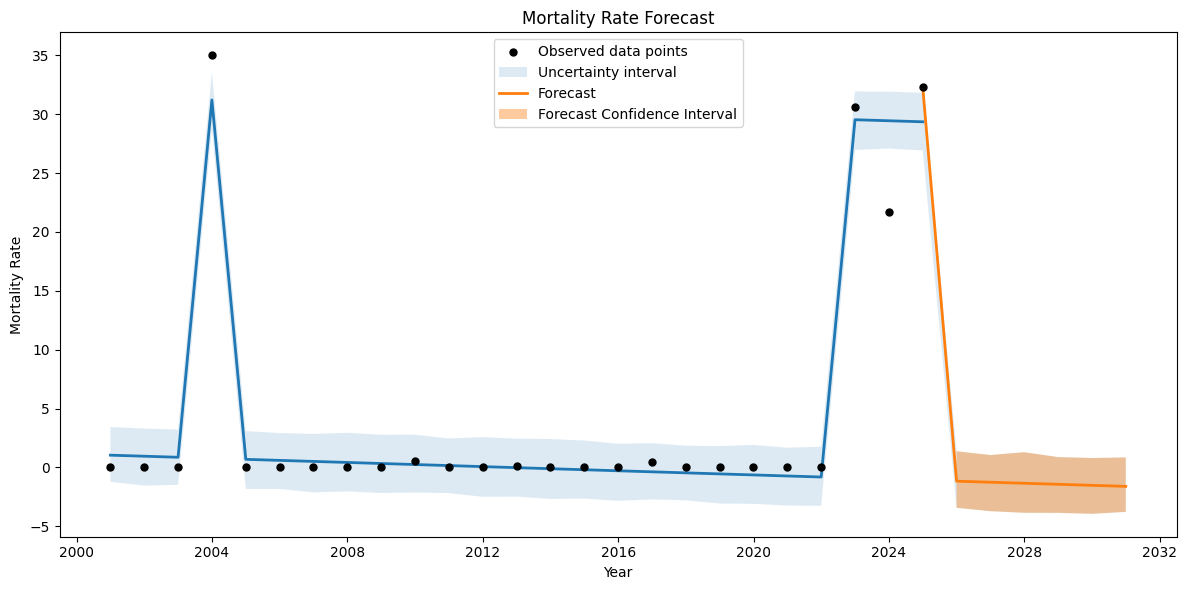

In [48]:
italy_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.5. Mexico

In [50]:
mexico = prepare_level_data(df,level='country', filter='Mexico')
mexico_model = ProphetModel(mexico)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2000,2013,2017, 2024]
mexico_forecast = mexico_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(mexico_forecast)

17:44:21 - cmdstanpy - INFO - Chain [1] start processing
17:44:22 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.046040   -0.016154    0.107526     0.046040     0.046040   
26 2026-12-31  0.045307   -0.021121    0.107295     0.045307     0.045307   
27 2027-12-31  0.044574   -0.017844    0.104858     0.044574     0.044574   
28 2028-12-31  0.043839   -0.016502    0.105082     0.043839     0.043839   
29 2029-12-31  0.043106   -0.020468    0.107455     0.043106     0.043106   
30 2030-12-31  0.042373   -0.019960    0.104678     0.042373     0.042373   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:44:25 - cmdstanpy - INFO - Chain [1] start processing
17:44:25 - cmdstanpy - INFO - Chain [1] done processing


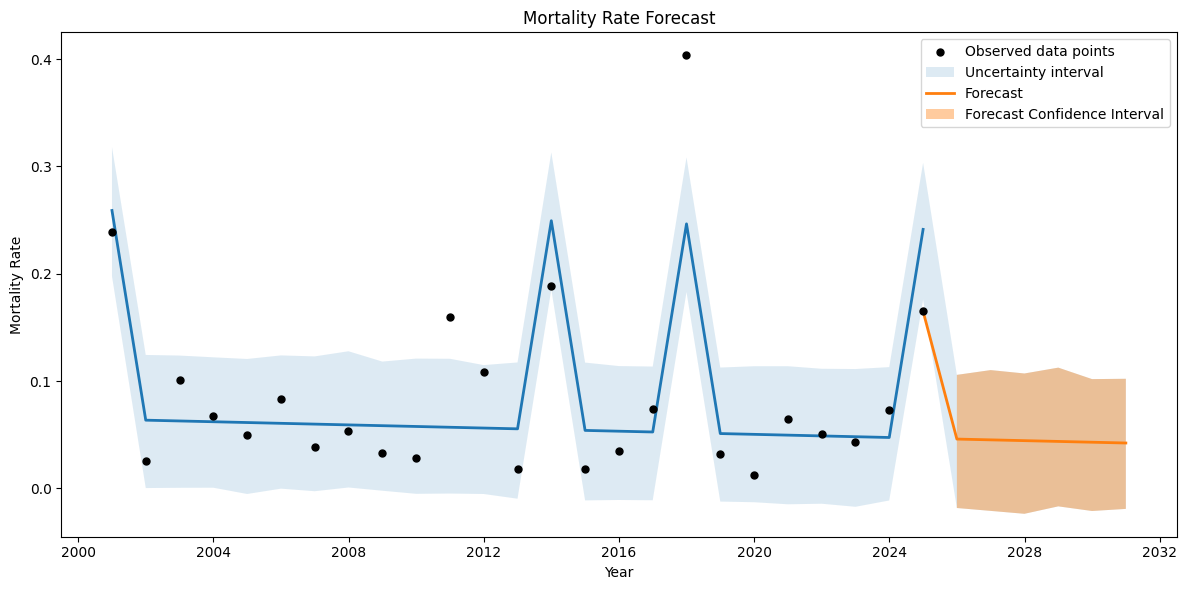

In [51]:
mexico_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.6. Sudan

In [52]:
sudan = prepare_level_data(df,level='country', filter='Sudan')
sudan_model = ProphetModel(sudan)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2005, 2006, 2007, 2017, 2024]
sudan_forecast = sudan_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(sudan_forecast)

17:45:54 - cmdstanpy - INFO - Chain [1] start processing
17:45:55 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.218265   -0.221321    0.689007     0.218265     0.218265   
26 2026-12-31  0.217968   -0.306532    0.673383     0.217968     0.217968   
27 2027-12-31  0.217672   -0.321094    0.701723     0.217672     0.217672   
28 2028-12-31  0.217375   -0.268925    0.735490     0.217375     0.217375   
29 2029-12-31  0.217079   -0.290008    0.715889     0.217079     0.217079   
30 2030-12-31  0.216783   -0.249745    0.705337     0.216783     0.216783   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:45:58 - cmdstanpy - INFO - Chain [1] start processing
17:45:58 - cmdstanpy - INFO - Chain [1] done processing


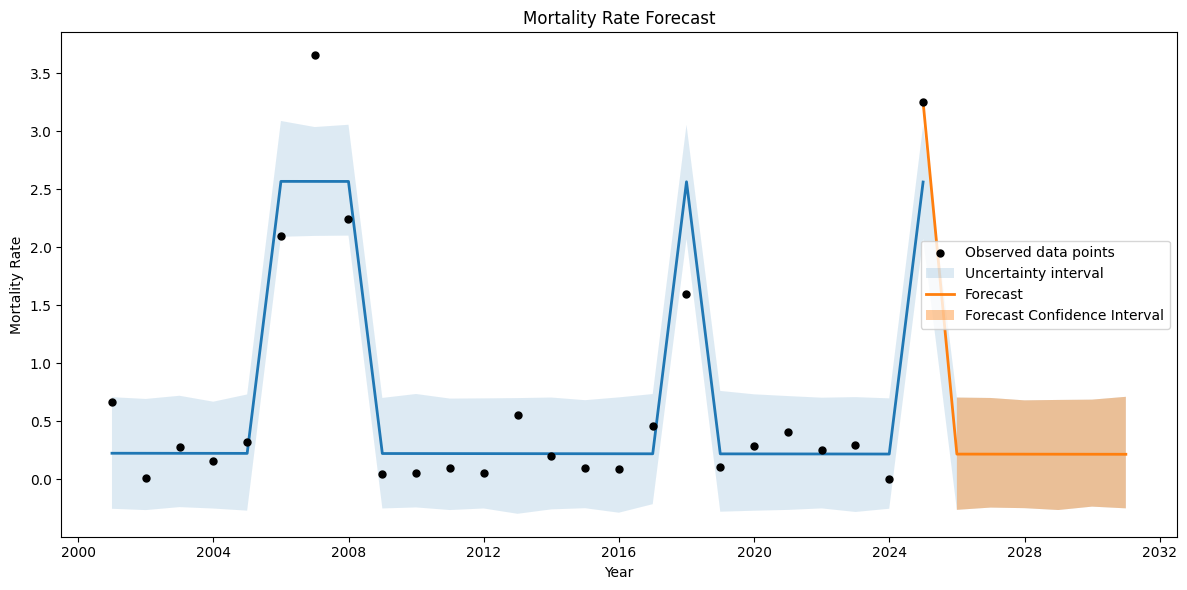

In [53]:
sudan_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.7. Türkiye

In [55]:
turkey = prepare_level_data(df,level='country', filter='Türkiye')
turkey_model = ARIMAModel(turkey)
turkey_forecast = turkey_model.arima_forecast(0, 0, 0, steps=6)
print(turkey_forecast)


Mortality_Rate      mean    mean_se  mean_ci_lower  mean_ci_upper
25              2.580184  12.167329     -21.267343      26.427711
26              2.580184  12.167329     -21.267343      26.427711
27              2.580184  12.167329     -21.267343      26.427711
28              2.580184  12.167329     -21.267343      26.427711
29              2.580184  12.167329     -21.267343      26.427711
30              2.580184  12.167329     -21.267343      26.427711


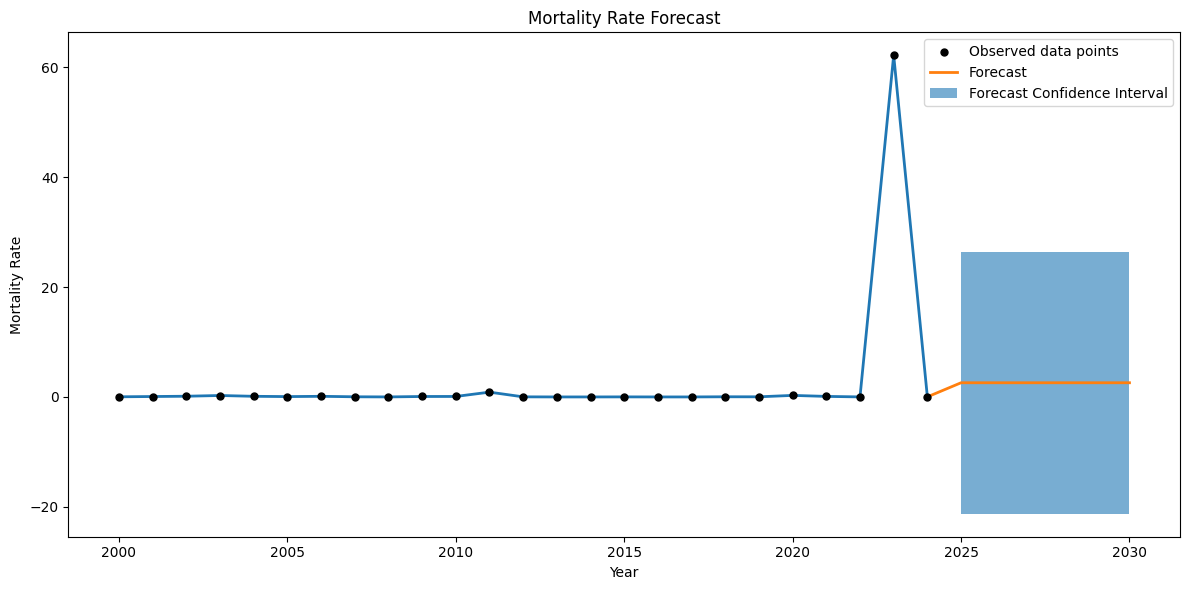

In [56]:
turkey_model.plot_forecast(0, 0, 0, steps=6)

### 2.3.8. Canada

In [57]:
canada = prepare_level_data(df,level='country', filter='Canada')
canada_model = ProphetModel(canada)
best_params = {
    "changepoint_prior_scale": float(0.2),
    "holidays_prior_scale": float(15.0)}
holiday_years = [2018,2021]
canada_forecast = canada_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(canada_forecast)

17:49:22 - cmdstanpy - INFO - Chain [1] start processing
17:49:22 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.043866   -0.325417    0.411203     0.043865     0.043866   
26 2026-12-31  0.046153   -0.305604    0.418401     0.046152     0.046155   
27 2027-12-31  0.048441   -0.312301    0.392328     0.048438     0.048444   
28 2028-12-31  0.050735   -0.300411    0.412782     0.050730     0.050740   
29 2029-12-31  0.053023   -0.306890    0.415604     0.053015     0.053030   
30 2030-12-31  0.055310   -0.331541    0.401986     0.055300     0.055320   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

17:49:23 - cmdstanpy - INFO - Chain [1] start processing
17:49:23 - cmdstanpy - INFO - Chain [1] done processing


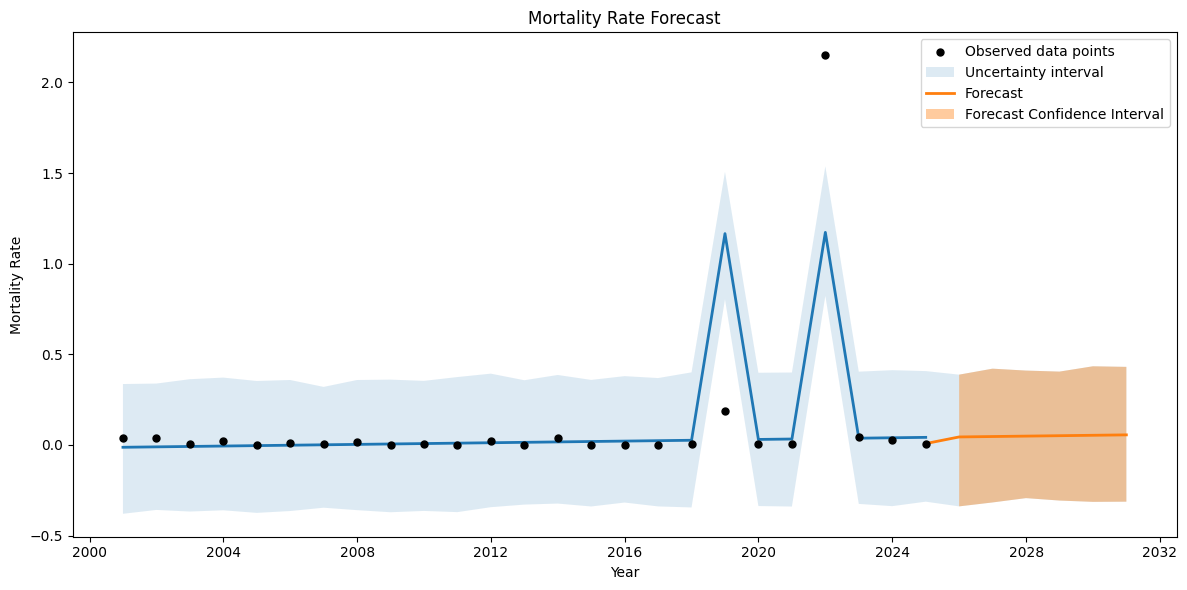

In [58]:
canada_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.9. United States of America

In [59]:
america = prepare_level_data(df,level='country', filter='United States of America')
america_model = ARIMAModel(america)
america_forecast = america_model.arima_forecast(1, 1, 0, steps=6)
print(america_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              0.306358  0.168145      -0.023200       0.635916
26              0.363364  0.191143      -0.011270       0.737997
27              0.337176  0.229149      -0.111947       0.786299
28              0.349206  0.254220      -0.149055       0.847467
29              0.343679  0.280091      -0.205289       0.892648
30              0.346218  0.302452      -0.246577       0.939014


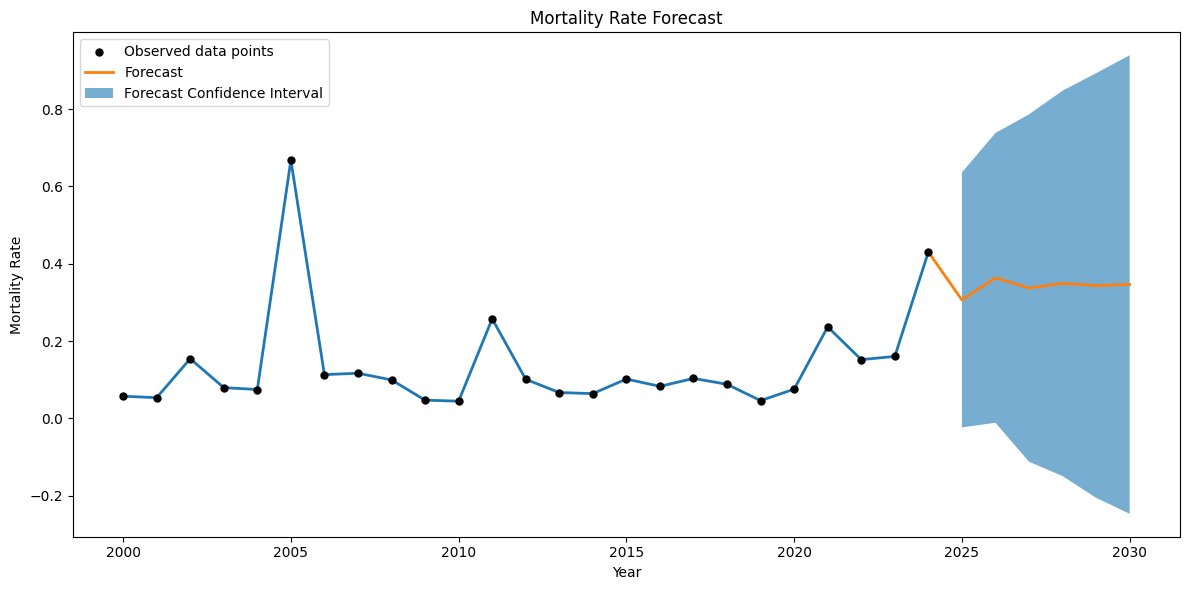

In [60]:
america_model.plot_forecast(1, 1, 0, steps=6)

### 2.3.10. India

In [61]:
india = prepare_level_data(df,level='country', filter='India')
india_model = ARIMAModel(india)
india_forecast = india_model.arima_forecast(1, 1, 1, steps=6)
print(india_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              0.152911  0.434764      -0.699210       1.005032
26              0.136374  0.434797      -0.715811       0.988560
27              0.141950  0.459991      -0.759616       1.043515
28              0.140070  0.471021      -0.783113       1.063253
29              0.140704  0.485526      -0.810909       1.092316
30              0.140490  0.498331      -0.836220       1.117201


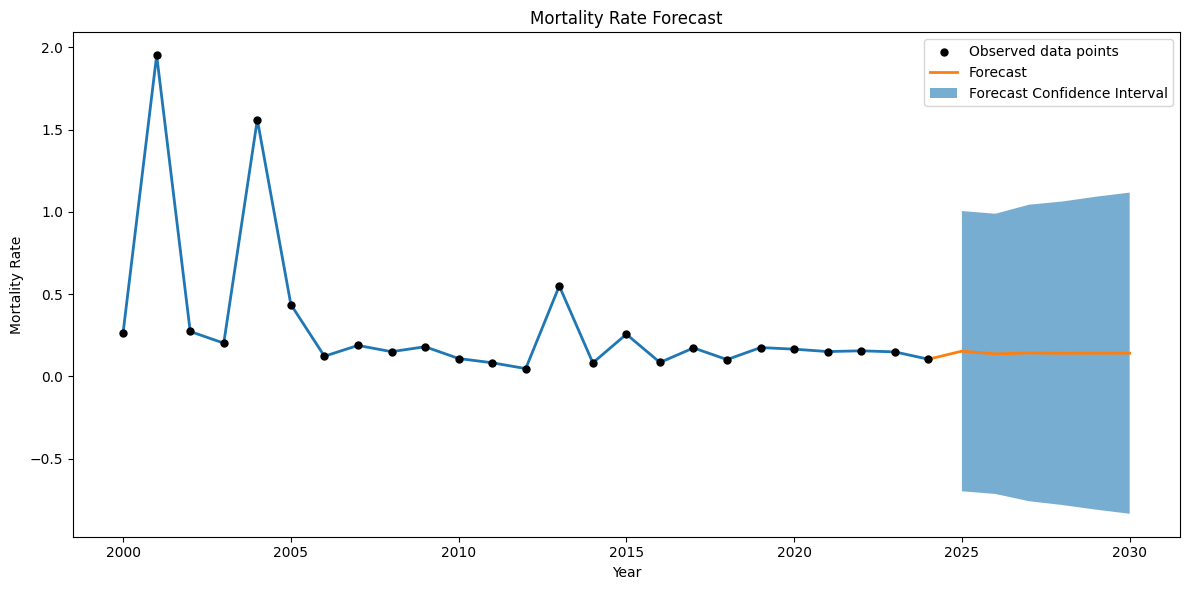

In [62]:
india_model.plot_forecast(1, 1, 1, steps=6)

### 2.3.11. Pakistan

In [65]:
pakistan = prepare_level_data(df,level='country', filter='Pakistan')
pakistan_model = ARIMAModel(pakistan)
pakistan_forecast = pakistan_model.arima_forecast(1, 1, 0, steps=6)
print(pakistan_forecast)

Mortality_Rate      mean    mean_se  mean_ci_lower  mean_ci_upper
25              0.295856  10.500717     -20.285170      20.876883
26              0.361395  11.804970     -22.775921      23.498712
27              0.329521  14.191978     -27.486246      28.145287
28              0.345023  15.681032     -30.389235      31.079281
29              0.337483  17.278861     -33.528462      34.203429
30              0.341150  18.632174     -36.177240      36.859541


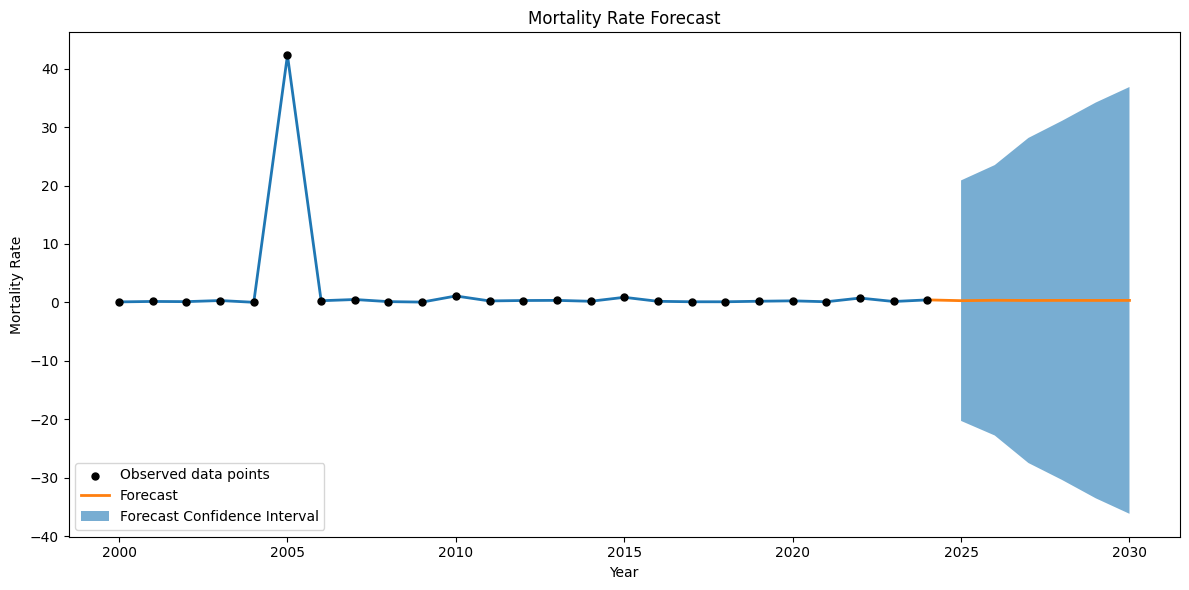

In [66]:
pakistan_model.plot_forecast(1, 1, 0, steps=6)

### 2.3.12. South Africa

In [67]:
south_africa = prepare_level_data(df,level='country', filter='South Africa')
south_africa_model = ProphetModel(south_africa)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2000,2002,2022]
south_africa_forecast = south_africa_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(south_africa_forecast)

18:17:06 - cmdstanpy - INFO - Chain [1] start processing
18:17:06 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.150038    0.024256    0.258874     0.150038     0.150038   
26 2026-12-31  0.156912    0.025473    0.281513     0.156912     0.156912   
27 2027-12-31  0.163786    0.036993    0.294936     0.163786     0.163786   
28 2028-12-31  0.170680    0.040613    0.295201     0.170680     0.170680   
29 2029-12-31  0.177554    0.057750    0.300774     0.177554     0.177554   
30 2030-12-31  0.184428    0.062899    0.311064     0.184428     0.184428   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

18:17:07 - cmdstanpy - INFO - Chain [1] start processing
18:17:07 - cmdstanpy - INFO - Chain [1] done processing


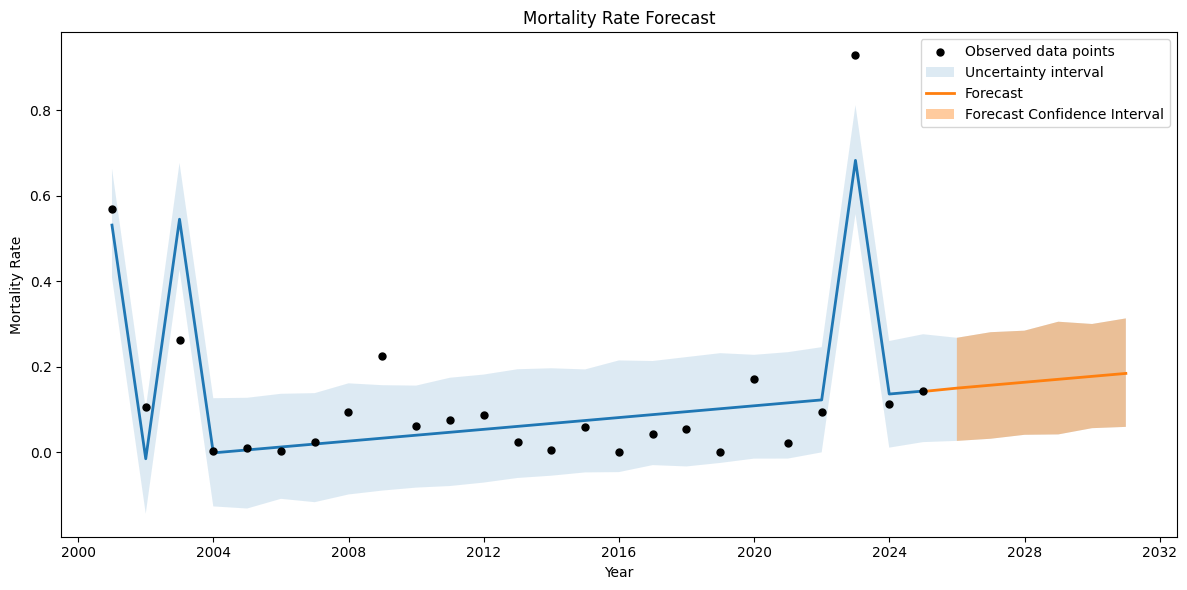

In [68]:
south_africa_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.13. Kenya

In [69]:
kenya = prepare_level_data(df,level='country', filter='Kenya')
kenya_model = ARIMAModel(kenya)
kenya_forecast = kenya_model.arima_forecast(0, 0, 0, steps=6)

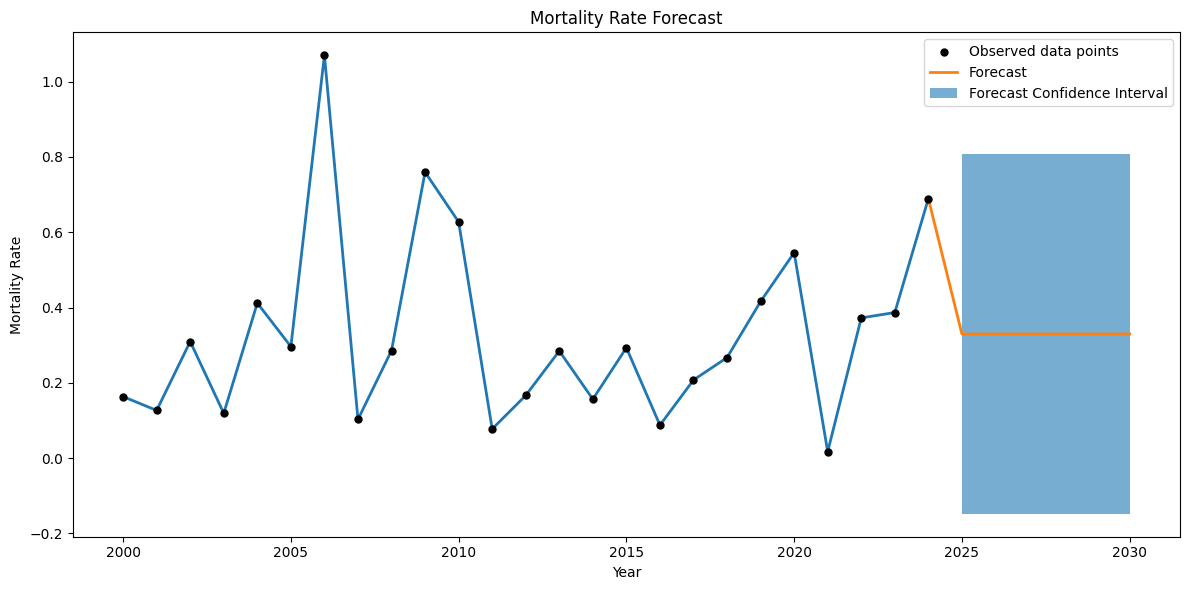

In [70]:
kenya_model.plot_forecast(0, 0, 0, steps=6)

### 2.3.14. Brazil

In [71]:
brazil = prepare_level_data(df,level='country', filter='Brazil')
brazil_model = ProphetModel(brazil)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2011]
brazil_forecast = brazil_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(brazil_forecast)

18:19:15 - cmdstanpy - INFO - Chain [1] start processing
18:19:15 - cmdstanpy - INFO - Chain [1] done processing


           ds     trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
25 2025-12-31  0.092598    0.014464    0.176785     0.092598     0.092598   
26 2026-12-31  0.093814    0.010419    0.171013     0.093814     0.093814   
27 2027-12-31  0.095030    0.011341    0.177701     0.095030     0.095030   
28 2028-12-31  0.096249    0.019474    0.181754     0.096249     0.096249   
29 2029-12-31  0.097465    0.013275    0.181387     0.097465     0.097465   
30 2030-12-31  0.098682    0.012222    0.180583     0.098682     0.098682   

    additive_terms  additive_terms_lower  additive_terms_upper  custom_event  \
25             0.0                   0.0                   0.0           0.0   
26             0.0                   0.0                   0.0           0.0   
27             0.0                   0.0                   0.0           0.0   
28             0.0                   0.0                   0.0           0.0   
29             0.0                   0.0                   0

18:19:16 - cmdstanpy - INFO - Chain [1] start processing
18:19:16 - cmdstanpy - INFO - Chain [1] done processing


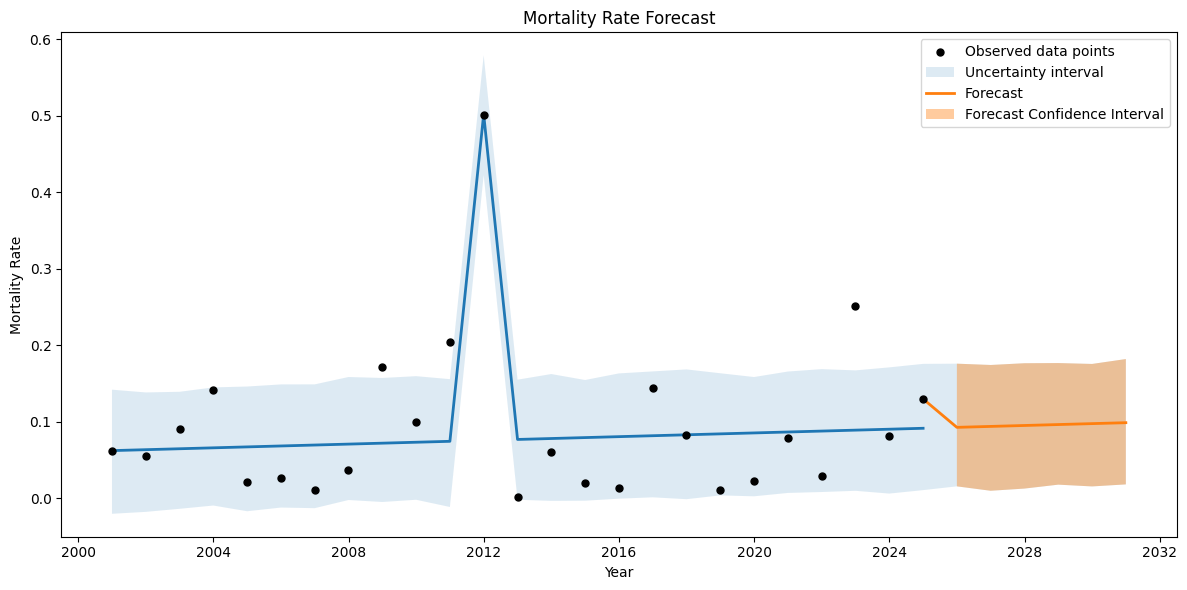

In [72]:
brazil_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)